# Exploratory Data Analysis (EDA) - Housing Dataset

## Overview
This notebook performs a comprehensive Exploratory Data Analysis on a housing dataset. EDA is a critical first step in any data science project that helps us understand the structure, quality, and patterns in our data before building predictive models.

## Objectives
1. **Data Understanding**: Load and examine the basic structure of the dataset
2. **Data Quality Assessment**: Identify missing values, data types, and potential issues
3. **Pattern Discovery**: Uncover relationships between variables
4. **Data Preparation**: Prepare insights for data cleaning and feature engineering

## Key Concepts Covered
- Data loading and initial exploration
- Missing value analysis and visualization
- Statistical summaries and distributions
- Data quality assessment

---

## Step 1: Import Essential Libraries

### Required Libraries for EDA:
- **NumPy (`np`)**: Fundamental package for numerical computing in Python
  - Provides support for large, multi-dimensional arrays and matrices
  - Essential mathematical functions for array operations

- **Pandas (`pd`)**: Primary data manipulation and analysis library
  - DataFrame and Series data structures for structured data
  - Tools for reading/writing data, data cleaning, and transformation

- **Seaborn (`sns`)**: Statistical data visualization library built on matplotlib
  - High-level interface for creating attractive and informative statistical graphics
  - Built-in themes and color palettes for professional visualizations

- **Matplotlib (`plt`)**: Fundamental plotting library for Python
  - Low-level plotting capabilities and customization
  - Foundation for most other Python visualization libraries

**Why These Libraries?** These four libraries form the core toolkit for data analysis in Python, providing everything needed for data loading, manipulation, statistical analysis, and visualization.

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Step 2: Load and Initial Data Exploration

### Loading the Dataset
- **`pd.read_csv('train.csv')`**: Reads a comma-separated values (CSV) file into a pandas DataFrame
  - CSV is the most common format for tabular data
  - Automatically infers column names from the first row
  - Returns a DataFrame object with rows and columns

### Initial Data Inspection
- **`.head()`**: Displays the first 5 rows of the dataset by default
  - **Purpose**: Quick visual inspection of data structure and content
  - **What to look for**: Column names, data types, sample values, obvious patterns or issues
  - **Parameters**: Can specify number of rows (e.g., `.head(10)` for first 10 rows)

In [41]:
data = pd.read_csv('train.csv')
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Understanding Dataset Dimensions
- **`.shape`**: Returns a tuple showing the dimensions of the DataFrame
  - **Format**: (number_of_rows, number_of_columns)
  - **Why Important**: Helps understand the scale of your dataset
  - **Interpretation**: 
    - Large datasets (>100k rows) may require different analysis strategies
    - Many columns (>50) might indicate need for dimensionality reduction
    - Few rows (<1000) might suggest limited statistical power

In [42]:
data.shape

(1460, 81)

### Comprehensive Data Information
- **`.info()`**: Provides a comprehensive overview of the DataFrame structure
  - **Data Types**: Shows whether columns are numeric (int64, float64) or text (object)
  - **Non-Null Count**: Reveals missing values by showing count of non-null entries per column
  - **Memory Usage**: Indicates how much RAM the dataset consumes
  - **Index Information**: Shows the range and type of row indices

**Key Insights from .info():**
- **Data Type Issues**: 'object' type might contain mixed data that needs cleaning
- **Missing Data**: Columns with fewer non-null counts than total rows have missing values
- **Memory Optimization**: Large memory usage might require data type optimization

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Exploring Categorical Variables
- **`.value_counts()`**: Counts unique values in a column and returns them in descending order
  - **Purpose**: Understand the distribution of categorical data
  - **Output**: Series with unique values as index and their frequencies as values
  - **Use Case**: Identify most/least common categories, detect imbalanced classes

- **`.head(10)`**: Shows only the top 10 most frequent values
  - **Why Limit Results**: Some categorical variables might have hundreds of unique values
  - **Pattern Recognition**: Helps identify if data is evenly distributed or dominated by few categories

**Analysis Focus - Neighborhood Variable:**
- Geographic features often strongly correlate with house prices
- Uneven distribution might indicate need for grouping rare neighborhoods
- High cardinality (many unique values) might require encoding strategies

In [44]:
data['Neighborhood'].value_counts().head(10)

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
Name: count, dtype: int64

## Step 3: Missing Value Analysis

### Why Missing Value Analysis is Critical:
Missing data is one of the most common and important issues in real-world datasets. Understanding patterns of missingness helps determine:
- **Data Quality**: How reliable is our dataset?
- **Analysis Strategy**: Which imputation methods to use?
- **Model Selection**: Some algorithms handle missing values better than others
- **Feature Engineering**: Missing values might be informative (Missing At Random vs Missing Not At Random)

### Initial Missing Value Detection
- **`.isnull().sum()`**: Counts missing values (NaN, None, pd.NaT) in each column
- **`.sort_values(ascending=False)`**: Orders columns by number of missing values (most missing first)
  - **Benefit**: Quickly identifies problematic columns that need attention
  - **Decision Making**: Columns with >70% missing might need to be dropped

In [45]:
# Count missing values per column
data.isnull().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

### Visual Missing Value Pattern Analysis
- **`sns.heatmap(data.isnull())`**: Creates a visual representation of missing values
  - **Color Coding**: Light areas = missing values, Dark areas = present values
  - **Pattern Recognition**: Reveals if missing values cluster in specific rows/columns
  - **Parameters Explained**:
    - `cbar=False`: Removes color bar (since we only have True/False values)
    - `cmap="viridis"`: Uses a perceptually uniform color palette
    - `figsize=(12,6)`: Sets figure dimensions for better visibility

**What to Look For:**
- **Random Patterns**: Missing values scattered randomly (Missing At Random - MAR)
- **Column Patterns**: Entire columns missing (systematic data collection issues)
- **Row Patterns**: Entire rows missing (specific time periods or data sources)
- **Block Patterns**: Missing values in related columns (related feature groups)

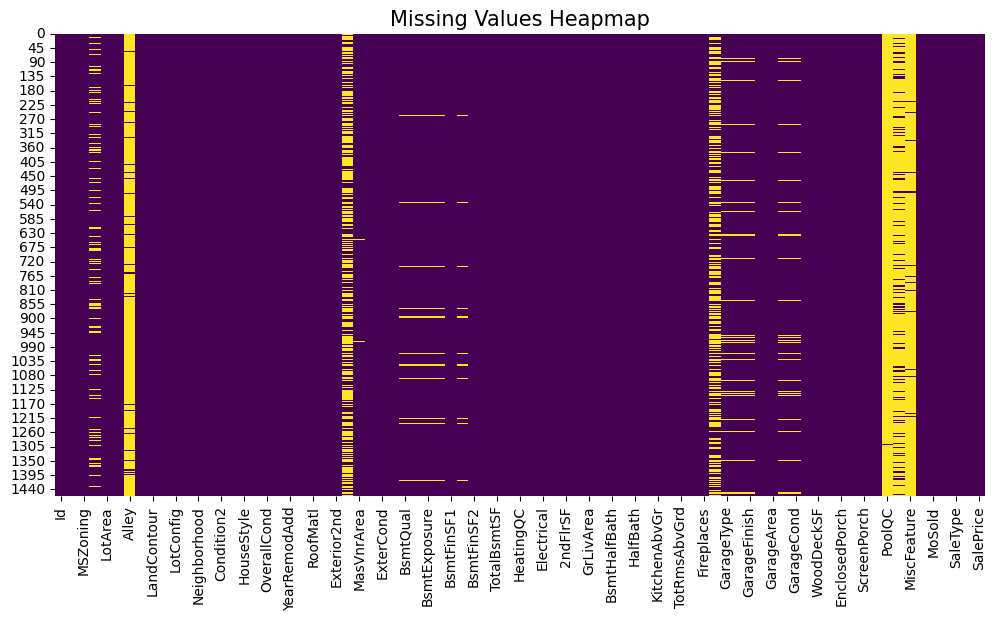

In [46]:
# Heatmap of missing values
plt.figure(figsize=(12,6))
sns.heatmap(data.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Values Heapmap",fontsize=15)
plt.show()

### Quantifying Missing Value Percentages
- **Percentage Calculation**: `(data.isnull().sum() / len(data)) * 100`
  - **Formula Breakdown**:
    - `data.isnull().sum()`: Count of missing values per column
    - `len(data)`: Total number of rows in dataset
    - Division gives proportion, multiplication by 100 gives percentage
  
- **Filtering Non-Zero Values**: `missing_precent[missing_precent>0]`
  - **Purpose**: Shows only columns that actually have missing values
  - **Efficiency**: Reduces output clutter and focuses attention on problematic columns

- **`.sort_values(ascending=False)`**: Orders from highest to lowest missing percentage
  - **Priority Setting**: Helps prioritize which columns need immediate attention
  - **Decision Rules**: 
    - >50% missing: Consider dropping column
    - 10-50% missing: Requires careful imputation strategy
    - <10% missing: Simple imputation often sufficient

In [47]:
missing_precent  = (data.isnull().sum() / len(data))*100
missing_precent  = missing_precent[missing_precent>0].sort_values(ascending=False)
missing_precent

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

### Alternative Approaches for Missing Value Detection

**Two Different Methods Demonstrated:**

#### Method 1 (Commented): `data.columns[data.isnull().any()]`
- **`.isnull().any()`**: Returns True for columns that have at least one missing value
- **`data.columns[...]`**: Selects column names where condition is True
- **Result**: List of column names with missing values
- **Use Case**: When you need column names for further processing

#### Method 2 (Active): Count-based filtering
- **Step 1**: `data.isnull().sum()` - Count missing values per column
- **Step 2**: `missing_value[missing_value>0]` - Filter columns with count > 0
- **Result**: Series with column names and their missing value counts
- **Advantage**: Provides both column names AND the count of missing values

**Why Show Both Methods?**
- **Learning**: Demonstrates multiple ways to solve the same problem
- **Flexibility**: Different methods suit different use cases
- **Pandas Proficiency**: Understanding various pandas operations increases efficiency

In [48]:
# Filter only columns with missing values
# missing_value = data.columns[data.isnull().any()] #1 approch
missing_value = data.isnull().sum()
missing_value = missing_value[missing_value>0] #2 approch
missing_value

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

### Converting Counts to Percentages
- **Formula**: `(missing_value/len(data))*100`
- **Purpose**: Percentages are more interpretable than raw counts
- **Benefits**:
  - **Scale Independence**: Easy to compare across datasets of different sizes
  - **Threshold Setting**: Industry standards often use percentage thresholds
  - **Communication**: Easier to explain to stakeholders ("20% missing" vs "146 missing out of 730")

In [49]:
# Show percentage also
missing_percentage = (missing_value/len(data))*100
missing_percentage

LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64

### Creating a Comprehensive Missing Value Summary

**DataFrame Construction**: `pd.DataFrame({"Missing Values": missing_value, "Missing %": missing_percentage.round(2)})`

#### Key Components:
- **Dictionary Structure**: Creates DataFrame from dictionary with descriptive column names
- **`.round(2)`**: Rounds percentages to 2 decimal places for cleaner presentation
- **`.sort_values("Missing %", ascending=False)`**: Orders by missing percentage (highest first)

#### Why Create This Summary Table?
1. **Professional Presentation**: Clean, organized view of missing data analysis
2. **Quick Reference**: Both count and percentage in one place
3. **Prioritization**: Sorted order helps prioritize data cleaning efforts
4. **Documentation**: Easy to include in reports or share with team members

#### Interpretation Guidelines:
- **>70% Missing**: Strong candidate for column removal
- **30-70% Missing**: Requires sophisticated imputation or domain expertise
- **10-30% Missing**: Standard imputation techniques often work well
- **<10% Missing**: Simple imputation (mean/mode) usually sufficient

In [50]:

# Combine into one table
missing_df = pd.DataFrame({"Missing Values": missing_value, 
                           "Missing %": missing_percentage.round(2)})

print(missing_df.sort_values("Missing %", ascending=False))

              Missing Values  Missing %
PoolQC                  1453      99.52
MiscFeature             1406      96.30
Alley                   1369      93.77
Fence                   1179      80.75
MasVnrType               872      59.73
FireplaceQu              690      47.26
LotFrontage              259      17.74
GarageType                81       5.55
GarageYrBlt               81       5.55
GarageFinish              81       5.55
GarageQual                81       5.55
GarageCond                81       5.55
BsmtExposure              38       2.60
BsmtFinType2              38       2.60
BsmtQual                  37       2.53
BsmtCond                  37       2.53
BsmtFinType1              37       2.53
MasVnrArea                 8       0.55
Electrical                 1       0.07


### Extracting Column Names with Missing Values
- **`.index`**: Accesses the index of a pandas Series
- **Purpose**: When `missing_value` is a Series, its index contains the column names
- **Use Case**: Getting list of problematic columns for:
  - Automated processing loops
  - Conditional logic in data cleaning
  - Feature selection algorithms
  - Reporting and documentation

**Practical Applications:**
```python
# Example uses of column names:
for col in missing_value.index:
    # Apply specific imputation strategy per column
    pass

# Or filter dataset to exclude problematic columns:
clean_data = data.drop(columns=missing_value.index)
```

In [51]:
missing_value.index

Index(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

## Step 4: Data Preparation for Further Analysis

### Creating a Working Copy
- **`dataset = data.copy()`**: Creates an independent copy of the original DataFrame
  - **Why Copy?**: Preserves original data while allowing modifications
  - **Memory Consideration**: Uses additional memory but provides safety net
  - **Best Practice**: Always work on copies during exploratory phase

### Setting Up Analysis Loop Structure
The incomplete loop structure suggests preparation for iterative analysis of columns with missing values. Common patterns include:

```python
# Typical analysis patterns:
for column in missing_value.index:
    # Analyze missing value patterns for each column
    # Apply column-specific imputation strategies
    # Visualize distributions before/after treatment
```

**Next Steps in EDA Workflow:**
1. **Individual Column Analysis**: Deep dive into each problematic column
2. **Missing Value Pattern Analysis**: Understand relationships between missing values
3. **Imputation Strategy Development**: Choose appropriate methods for each column
4. **Feature Engineering**: Create new features from missing value patterns
5. **Data Quality Validation**: Verify improvements after treatment

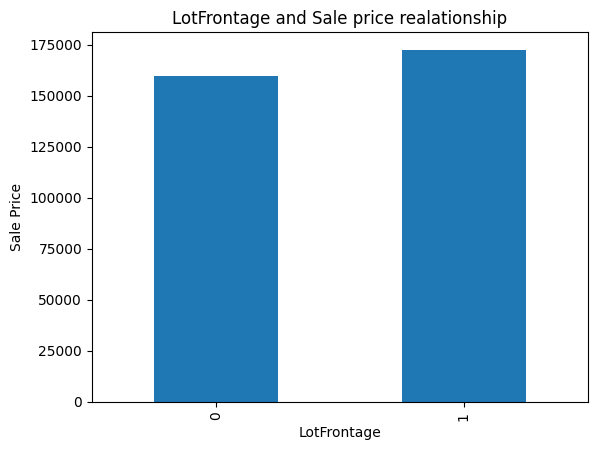

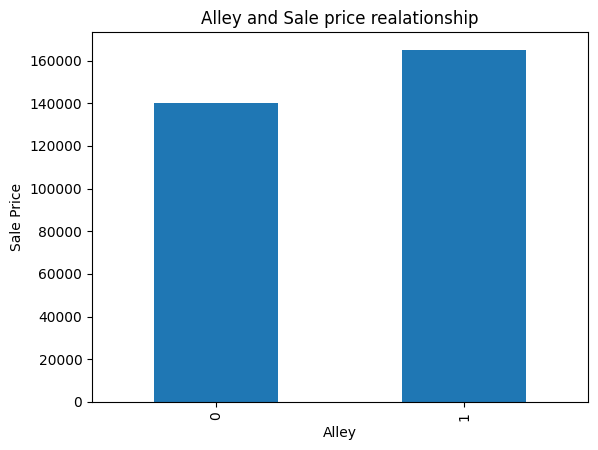

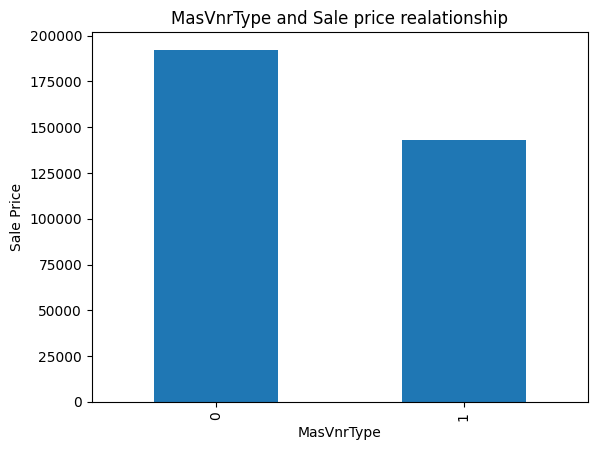

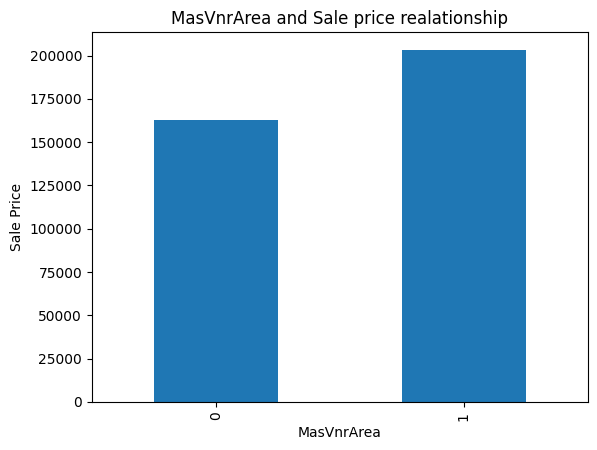

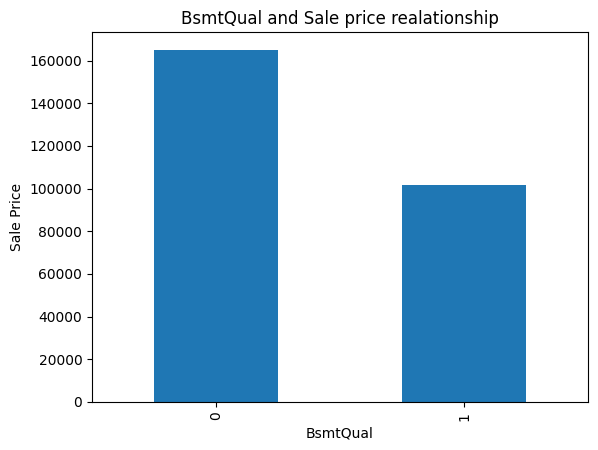

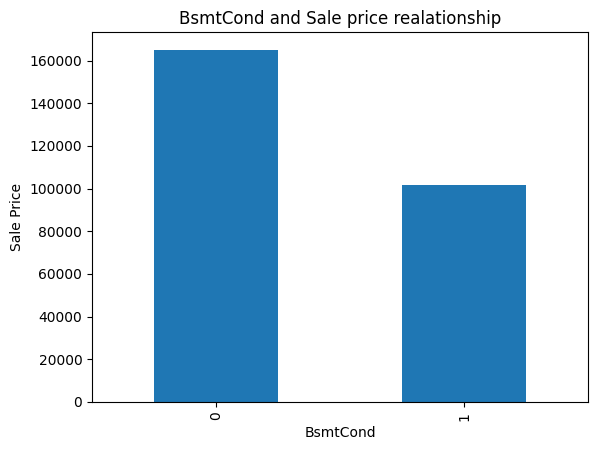

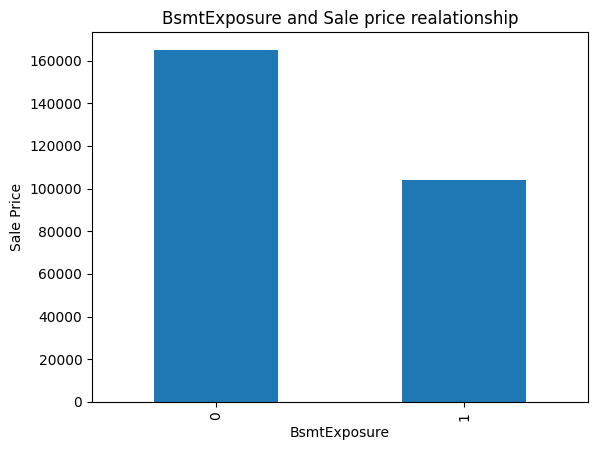

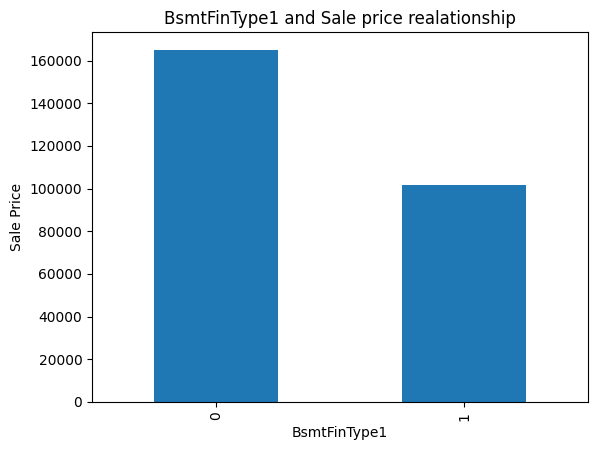

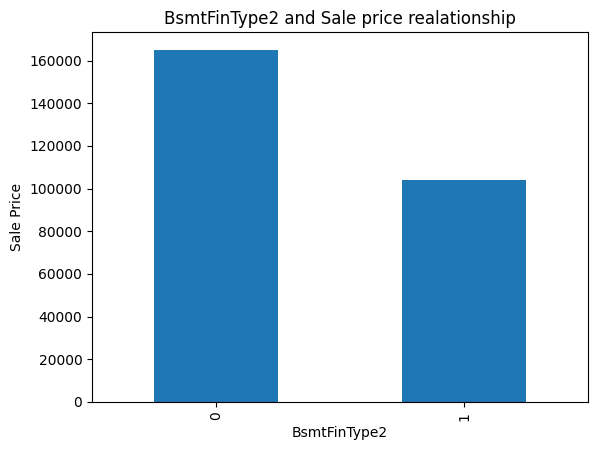

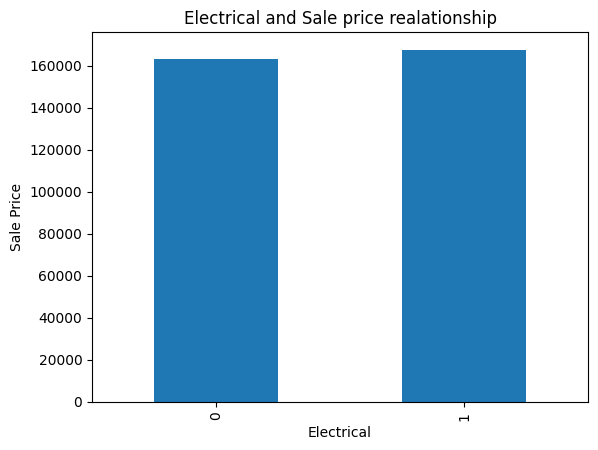

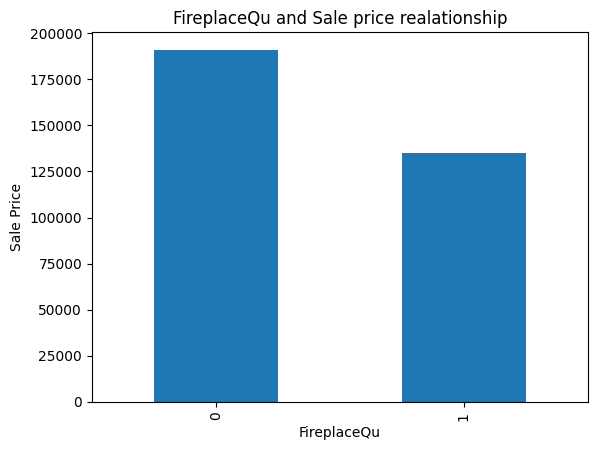

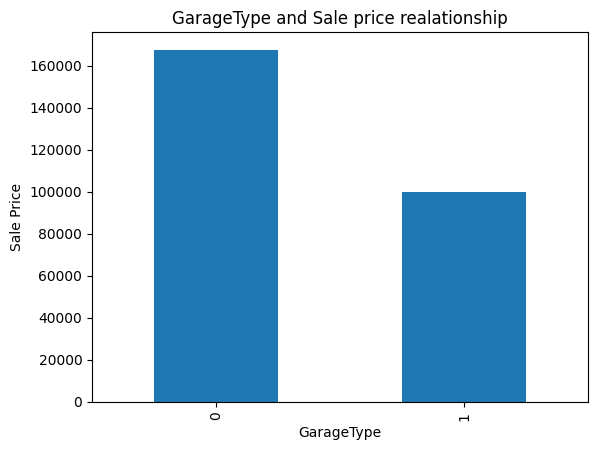

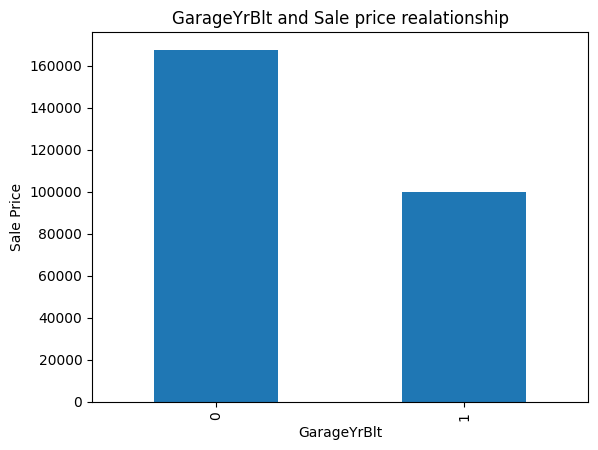

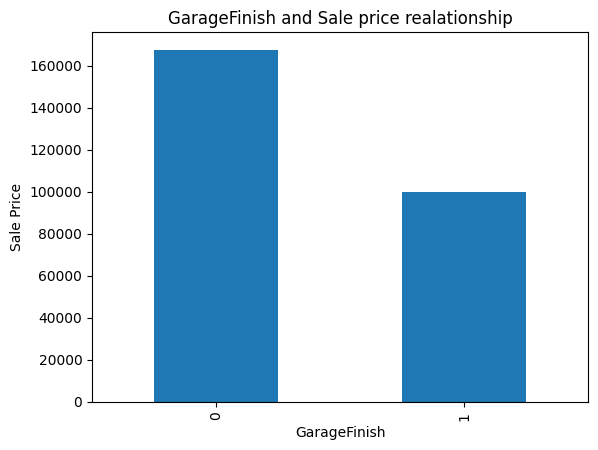

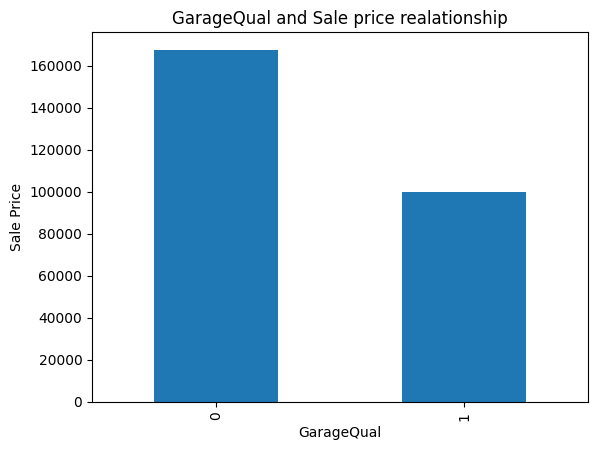

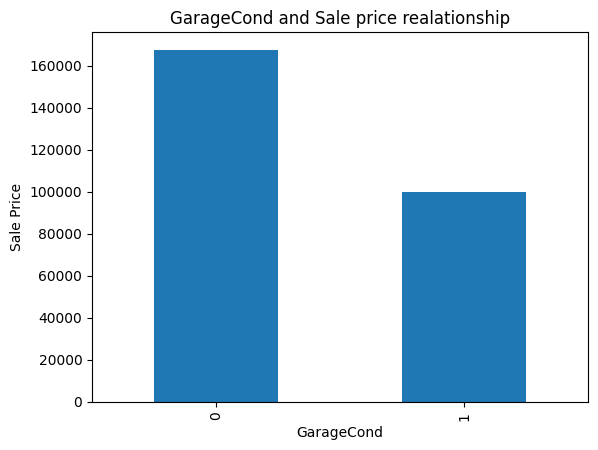

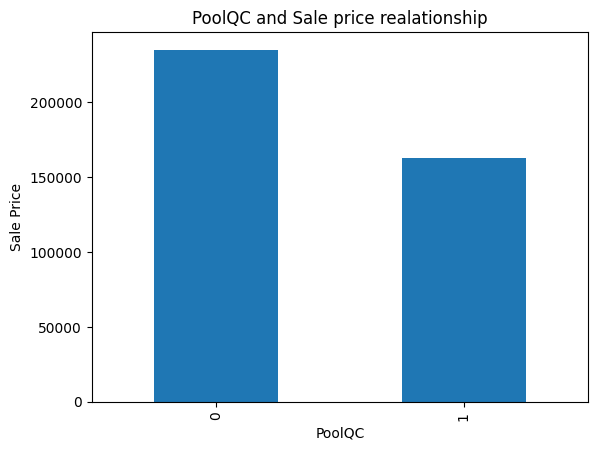

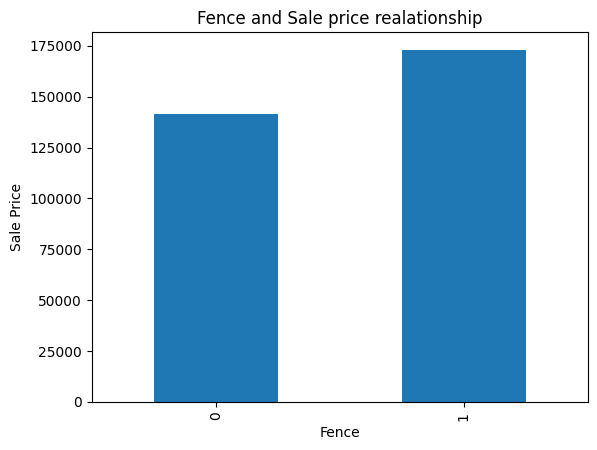

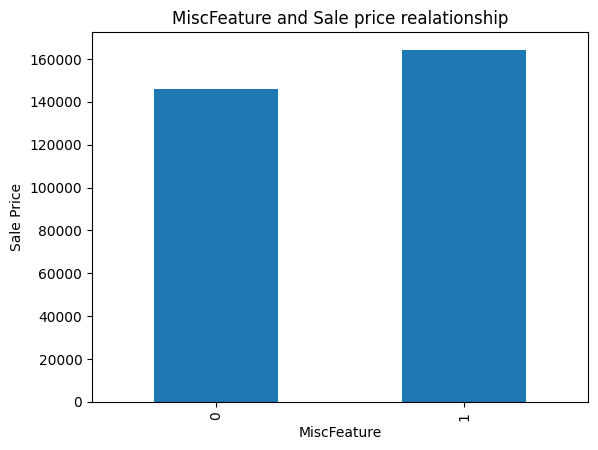

In [55]:
# Create a working copy of the data for analysis
dataset = data.copy()

for feature in missing_value.index:
    dataset[feature] = np.where(dataset[feature].isnull(),1,0)
    dataset.groupby(feature)["SalePrice"].median().plot(kind='bar')
    plt.xlabel(feature)
    plt.ylabel("Sale Price")
    plt.title(f"{feature} and Sale price realationship")
    plt.show()

In [66]:
#numerical Varibale
numerical_variable = data.select_dtypes(exclude='object')
len(numerical_variable.columns)

38

In [70]:
#Temoral Varibale
year_variable = [feature for feature in numerical_variable if "Yr" in feature or "Year" in feature]
year_variable

['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold']